<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/Parabolic_SAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_16370/3351492227.py:176: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=stdate, end=eddate, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


다운로드 완료: 503일치 데이터
매수(Long) 시그널: 2번
매도(Short) 시그널: 2번


/tmp/ipykernel_16370/3351492227.py:148: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(new.loc[new['signals'] == 1].index,


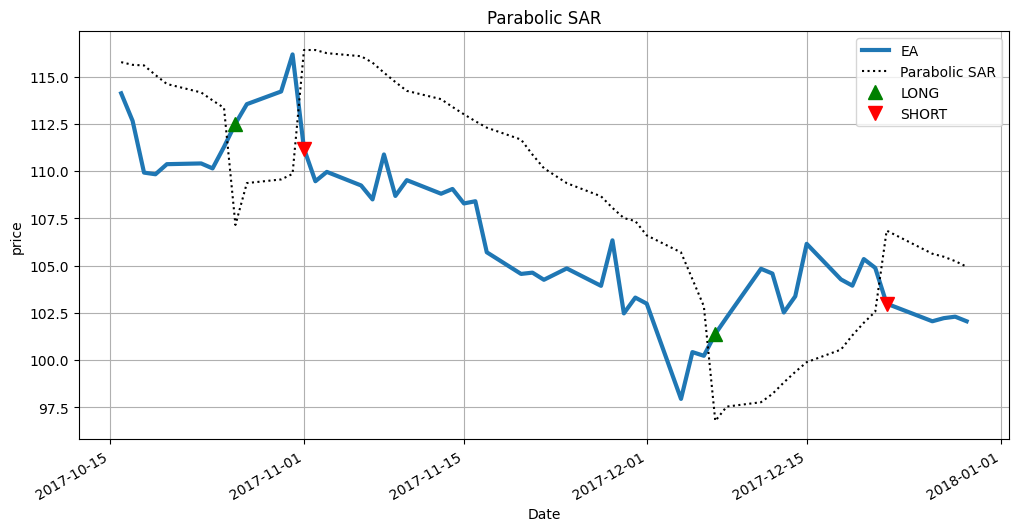

In [1]:
# -*- coding: utf-8 -*-
"""
=============================================================================
  6차시 실습: Parabolic SAR (파라볼릭 스탑 앤 리버스) — 코드 완성하기
=============================================================================
"""

# ===================================================================
# 문제 0. 라이브러리 불러오기
# ===================================================================

import matplotlib.pyplot as plt
import numpy as np               # 문제 0-1)
import yfinance as yf            # 문제 0-2)
import pandas as pd              # 문제 0-3)


# ===================================================================
# 문제 1. Parabolic SAR 계산 함수
# ===================================================================

def parabolic_sar(new):
    """Parabolic SAR을 재귀적으로 계산"""

    # 문제 1-1) AF 파라미터 설정
    initial_af = 0.02
    step_af = 0.02
    end_af = 0.2

    # 문제 1-2) 새 컬럼 5개 초기화
    new['trend'] = 0
    new['sar'] = 0.0
    new['real sar'] = 0.0
    new['ep'] = 0.0
    new['af'] = 0.0

    # 문제 1-3) 초기값 설정 (인덱스 1)
    new.loc[1, 'trend'] = 1 if new['Close'].iloc[1] > new['Close'].iloc[0] else -1

    new.loc[1, 'sar'] = new['High'].iloc[0] if new['trend'].iloc[1] > 0 else new['Low'].iloc[0]

    new.at[1, 'real sar'] = new['sar'].iloc[1]

    new.loc[1, 'ep'] = new['High'].iloc[1] if new['trend'].iloc[1] > 0 else new['Low'].iloc[1]

    new.loc[1, 'af'] = initial_af

    # 문제 1-4) 재귀 루프 (인덱스 2부터)
    for i in range(2, len(new)):

        # 1단계: SAR 후보값 계산
        temp = new['sar'].iloc[i-1] + new['af'].iloc[i-1] * (new['ep'].iloc[i-1] - new['sar'].iloc[i-1])

        # 2단계: SAR 확정 + 추세 반전 판단
        if new['trend'].iloc[i-1] < 0:
            # 하락추세: SAR = max(후보값, 최근2일 고가)
            new.at[i, 'sar'] = max(temp, new['High'].iloc[i-1], new['High'].iloc[i-2])

            # 반전 체크: SAR < 오늘 고가? → 상승 반전!
            if new['sar'].iloc[i] < new['High'].iloc[i]:
                temp = 1           # 문제 1-4a) 상승추세 시작
            else:
                temp = new['trend'].iloc[i-1] - 1   # 하락 계속

        else:
            # 상승추세: SAR = min(후보값, 최근2일 저가)
            new.at[i, 'sar'] = min(temp, new['Low'].iloc[i-1], new['Low'].iloc[i-2])

            # 반전 체크: SAR > 오늘 저가? → 하락 반전!
            if new['sar'].iloc[i] > new['Low'].iloc[i]:
                temp = -1          # 문제 1-4b) 하락추세 시작
            else:
                temp = new['trend'].iloc[i-1] + 1   # 상승 계속

        new.at[i, 'trend'] = temp

        # 3단계: EP(극단점) 업데이트
        if new['trend'].iloc[i] < 0:
            if new['trend'].iloc[i] != -1:      # 문제 1-4c) 하락 지속
                temp = min(new['Low'].iloc[i], new['ep'].iloc[i-1])
            else:
                temp = new['Low'].iloc[i]
        else:
            if new['trend'].iloc[i] != 1:       # 문제 1-4d) 상승 지속
                temp = max(new['High'].iloc[i], new['ep'].iloc[i-1])
            else:
                temp = new['High'].iloc[i]

        new.at[i, 'ep'] = temp

        # 4단계: AF 업데이트 + real SAR 결정
        if np.abs(new['trend'].iloc[i]) == 1:
            # 반전 직후
            temp = new['ep'].iloc[i-1]         # real SAR = 이전 EP
            new.at[i, 'af'] = initial_af       # AF 초기화
        else:
            # 지속 중
            temp = new['sar'].iloc[i]           # real SAR = 계산된 SAR
            if new['ep'].iloc[i] == new['ep'].iloc[i-1]:
                # EP 미갱신 → AF 유지
                new.at[i, 'af'] = new['af'].iloc[i-1]
            else:
                # EP 갱신 → AF 증가 (최대 end_af)
                new.at[i, 'af'] = min(end_af, new['af'].iloc[i-1] + step_af)

        new.at[i, 'real sar'] = temp

    return new


# ===================================================================
# 문제 2. 시그널 생성 함수
# ===================================================================

def signal_generation(df, method):
    """SAR 기반 매수/매도 시그널 생성"""

    # 문제 2-1) SAR 계산 함수 호출
    new = method(df)

    new['positions'] = 0
    new['signals'] = 0

    # 문제 2-2) 포지션 결정
    new['positions'] = np.where(new['real sar'] < new['Close'], 1, 0)

    # 문제 2-3) 시그널 추출
    new['signals'] = new['positions'].diff()

    return new


# ===================================================================
# 문제 3. 차트 시각화 함수
# ===================================================================

def plot(new, ticker):
    """Parabolic SAR + 매매 시그널 차트"""

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111)

    # 문제 3-1) 종가와 SAR 그리기
    new['Close'].plot(lw=3, label='%s' % ticker)
    new['real sar'].plot(linestyle=':', label='Parabolic SAR', color='k')

    # 문제 3-2) 매수(LONG) 마커: 초록색 ▲
    ax.plot(new.loc[new['signals'] == 1].index,
            new['Close'][new['signals'] == 1],
            marker='^', color='green', label='LONG', lw=0, markersize=10)

    # 문제 3-3) 매도(SHORT) 마커: 빨간색 ▼
    ax.plot(new.loc[new['signals'] == -1].index,
            new['Close'][new['signals'] == -1],
            marker='v', color='red', label='SHORT', lw=0, markersize=10)

    plt.legend()
    plt.grid(True)
    plt.title('Parabolic SAR')
    plt.ylabel('price')
    plt.show()


# ===================================================================
# 문제 4. 메인 실행 함수
# ===================================================================

stdate = '2016-01-01'
eddate = '2018-01-01'
ticker = 'EA'
slicer = 450

def main():

    # 문제 4-1) 데이터 다운로드 + 전처리
    df = yf.download(ticker, start=stdate, end=eddate, multi_level_index=False)
    df = df[['Open', 'High', 'Low', 'Close']].copy()
    df.reset_index(inplace=True)   # 문제 4-1a) 날짜→정수 인덱스 변환

    # 문제 4-2) 시그널 생성
    new = signal_generation(df, parabolic_sar)

    # 문제 4-3) 날짜 인덱스 복원 + 슬라이싱
    new.set_index(new['Date'], inplace=True)
    new = new[slicer:]

    # 결과 출력
    print(f"다운로드 완료: {len(df)}일치 데이터")
    longs = len(new[new['signals'] == 1])
    shorts = len(new[new['signals'] == -1])
    print(f"매수(Long) 시그널: {longs}번")
    print(f"매도(Short) 시그널: {shorts}번")

    # 문제 4-4) 차트 출력
    plot(new, ticker)


# ===================================================================
# 채점 도우미 (원본 그대로 유지)
# ===================================================================

def check_answers():
    """중간 결과를 확인하는 채점 함수"""
    import inspect
    print("=" * 60)
    print("  6차시 채점 시작")
    print("=" * 60)

    score = 0
    total = 8

    try:
        assert np.__name__ == 'numpy'
        assert yf.__name__ == 'yfinance'
        assert pd.__name__ == 'pandas'
        print("✅ 문제 0 통과: 라이브러리가 올바르게 import 되었습니다.")
        score += 1
    except:
        print("❌ 문제 0 실패: 라이브러리 import를 확인하세요.")

    try:
        df = yf.download('EA', start='2016-01-01', end='2018-01-01', multi_level_index=False)
        df = df[['Open', 'High', 'Low', 'Close']].copy()
        df.reset_index(inplace=True)
        assert len(df) > 400
        print(f"  → 데이터 다운로드 성공: {len(df)}행")
    except:
        print("❌ 데이터 다운로드 실패. 인터넷 연결을 확인하세요.")
        return

    try:
        result = parabolic_sar(df.copy())
        for col in ['trend', 'sar', 'real sar', 'ep', 'af']:
            assert col in result.columns, f"'{col}' 열이 없습니다."
        print("✅ 문제 1-2 통과: SAR 컬럼이 모두 존재합니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 1-2 실패: {e}")
        return

    try:
        assert result['trend'].iloc[1] in [1, -1]
        assert result['af'].iloc[1] == 0.02
        assert result['real sar'].iloc[1] != 0
        assert result['ep'].iloc[1] != 0
        print("✅ 문제 1-3 통과: 초기값이 올바릅니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 1-3 실패: {e}")

    try:
        non_zero = (result['trend'] != 0).sum()
        assert non_zero > len(result) * 0.9
        valid_af = result['af'].iloc[2:]
        assert (valid_af >= 0.02 - 0.001).all()
        assert (valid_af <= 0.20 + 0.001).all()
        print("✅ 문제 1-4 통과: 재귀 계산이 올바르게 작동합니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 1-4 실패: {e}")

    try:
        has_up = (result['trend'] > 0).any()
        has_down = (result['trend'] < 0).any()
        assert has_up and has_down
        reversal_count = ((result['trend'].abs() == 1) & (result.index > 1)).sum()
        assert reversal_count >= 2
        print(f"  → 추세 반전 횟수: {reversal_count}번")
        print("✅ 문제 1-4 (반전) 통과: 추세 반전이 감지됩니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 1-4 (반전) 실패: {e}")

    try:
        signals = signal_generation(df.copy(), parabolic_sar)
        assert 'positions' in signals.columns
        assert 'signals' in signals.columns
        pos_vals = set(signals['positions'].unique())
        assert pos_vals <= {0, 1}
        has_buy = (signals['signals'] == 1).any()
        has_sell = (signals['signals'] == -1).any()
        print(f"  → 매수 존재: {'✓' if has_buy else '✗'}, 매도 존재: {'✓' if has_sell else '✗'}")
        assert has_buy and has_sell
        print("✅ 문제 2 통과: 시그널 생성이 올바릅니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 2 실패: {e}")

    try:
        src = inspect.getsource(plot)
        assert "'real sar'" in src or '"real sar"' in src
        assert "'^'" in src
        assert "'v'" in src
        assert "linestyle" in src
        print("✅ 문제 3 통과: 차트 함수가 올바릅니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 3 실패: {e}")

    try:
        src = inspect.getsource(main)
        assert "reset_index" in src
        assert "set_index" in src
        assert "slicer" in src
        print("✅ 문제 4 통과: 메인 함수가 올바릅니다.")
        score += 1
    except Exception as e:
        print(f"❌ 문제 4 실패: {e}")

    print()
    print("=" * 60)
    print(f"  결과: {score}/{total} 통과")
    if score == total:
        print("  🎉 모든 문제를 맞혔습니다! main()을 실행해서 차트를 확인하세요.")
    elif score >= 6:
        print("  👍 거의 다 맞혔습니다! 틀린 부분을 확인해보세요.")
    elif score >= 4:
        print("  📖 절반 이상입니다. 교재를 참고해서 나머지를 완성하세요.")
    else:
        print("  📖 교재(06_parabolic_sar_detailed.md)를 다시 읽어보고 도전하세요.")
    print("=" * 60)


# ===================================================================
# 실행
# ===================================================================
if __name__ == '__main__':
    # check_answers()
    main()